# Phase 1: Machine Learning Classifiers from Scratch
Three classifiers (Logistic Regression, KNN, SVC) built from scratch with NumPy and evaluated on binary MNIST classification (digit 3 vs. rest).

## 0. Custom Classifiers
Logistic Regression, K-Nearest Neighbors, and Support Vector Classifier — implemented from scratch with NumPy only.

In [1]:
import numpy as np
from collections import Counter

# ═══════════════════════════════════════════════════════════════════════════════
#  Base
# ═══════════════════════════════════════════════════════════════════════════════

class _BaseClassifier:
    """Shared helpers for all classifiers."""

    def _encode_labels(self, y):
        """Map arbitrary labels to 0 … K-1 and store the mapping."""
        self.classes_ = np.unique(y)
        self._label_to_idx = {c: i for i, c in enumerate(self.classes_)}
        return np.array([self._label_to_idx[v] for v in y])

    def _decode_labels(self, idx):
        return self.classes_[idx]

# ═══════════════════════════════════════════════════════════════════════════════
#  Logistic Regression (With Loss Tracking)
# ═══════════════════════════════════════════════════════════════════════════════

class LogisticRegression(_BaseClassifier):
    def __init__(self, lr=0.01, max_iter=1000, C=1.0, tol=1e-6, fit_intercept=True):
        self.lr = lr
        self.max_iter = max_iter
        self.C = C
        self.tol = tol
        self.fit_intercept = fit_intercept

    @staticmethod
    def _sigmoid(z):
        pos = z >= 0
        result = np.empty_like(z, dtype=float)
        result[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        exp_z = np.exp(z[~pos])
        result[~pos] = exp_z / (1.0 + exp_z)
        return result

    def _add_intercept(self, X):
        if self.fit_intercept:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _fit_binary(self, X, y):
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        reg = 1.0 / self.C
        prev_loss = np.inf

        loss_history = []

        for _ in range(self.max_iter):
            z = X @ w
            h = self._sigmoid(z)

            # Calculate Cross-Entropy Loss + L2 Penalty
            eps = 1e-15
            loss = (-1 / n_samples) * (
                y @ np.log(h + eps) + (1 - y) @ np.log(1 - h + eps)
            ) + 0.5 * reg * np.dot(w, w)

            loss_history.append(loss)

            grad = (1 / n_samples) * (X.T @ (h - y)) + reg * w
            w -= self.lr * grad

            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        return w, loss_history

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y_enc = self._encode_labels(y)
        X = self._add_intercept(X)

        self.weights_ = []
        self.loss_histories_ = []

        for k in range(len(self.classes_)):
            binary_y = (y_enc == k).astype(float)
            w, history = self._fit_binary(X, binary_y)

            self.weights_.append(w)
            self.loss_histories_.append(history)

        self.weights_ = np.array(self.weights_)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        X = self._add_intercept(X)
        logits = X @ self.weights_.T
        probs = self._sigmoid(logits)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self._decode_labels(np.argmax(probs, axis=1))


# ═══════════════════════════════════════════════════════════════════════════════
#  K-Nearest Neighbours Classifier (FIXED)
# ═══════════════════════════════════════════════════════════════════════════════

class KNeighborsClassifier(_BaseClassifier):
    def __init__(self, n_neighbors=5, weights="uniform", p=2):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.p = p

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        self._encode_labels(y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        predictions = []
        batch_size = 250  # Process 250 queries at a time to save memory

        for i in range(0, X.shape[0], batch_size):
            X_batch = X[i : i + batch_size]
            # Compute distance for the batch
            diff = X_batch[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]
            dists = np.sum(np.abs(diff) ** self.p, axis=2) ** (1.0 / self.p)
            nn_idx = np.argsort(dists, axis=1)[:, : self.n_neighbors]

            for j, neighbours in enumerate(nn_idx):
                labels = self.y_train_[neighbours]
                if self.weights == "distance":
                    d = dists[j, neighbours]
                    d = np.where(d == 0, 1e-10, d)
                    w = 1.0 / d
                    vote = {}
                    for lbl, weight in zip(labels, w):
                        vote[lbl] = vote.get(lbl, 0.0) + weight
                    predictions.append(max(vote, key=vote.get))
                else:
                    counter = Counter(labels)
                    predictions.append(counter.most_common(1)[0][0])
        return np.array(predictions)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        n_classes = len(self.classes_)
        proba = np.zeros((X.shape[0], n_classes))
        batch_size = 250

        for i in range(0, X.shape[0], batch_size):
            X_batch = X[i : i + batch_size]
            diff = X_batch[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]
            dists = np.sum(np.abs(diff) ** self.p, axis=2) ** (1.0 / self.p)
            nn_idx = np.argsort(dists, axis=1)[:, : self.n_neighbors]

            for j, neighbours in enumerate(nn_idx):
                global_idx = i + j
                labels = self.y_train_[neighbours]
                y_enc = np.array([self._label_to_idx[l] for l in labels])
                if self.weights == "distance":
                    d = dists[j, neighbours]
                    d = np.where(d == 0, 1e-10, d)
                    w = 1.0 / d
                else:
                    w = np.ones(len(neighbours))
                for cls_idx, weight in zip(y_enc, w):
                    proba[global_idx, cls_idx] += weight
                proba[global_idx] /= proba[global_idx].sum()
        return proba
# ═══════════════════════════════════════════════════════════════════════════════
#  Support Vector Classifier (With Convergence Tracking)
# ═══════════════════════════════════════════════════════════════════════════════

class SVC(_BaseClassifier):
    def __init__(self, C=1.0, kernel="rbf", gamma="scale", degree=3,
                 coef0=0.0, tol=1e-3, max_iter=1000):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.tol = tol
        self.max_iter = max_iter

    def _compute_kernel(self, X1, X2):
        if self.kernel == "linear":
            return X1 @ X2.T
        elif self.kernel == "poly":
            return (self._gamma * (X1 @ X2.T) + self.coef0) ** self.degree
        elif self.kernel == "rbf":
            sq1 = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
            sq2 = np.sum(X2 ** 2, axis=1).reshape(1, -1)
            dist_sq = sq1 + sq2 - 2 * (X1 @ X2.T)
            return np.exp(-self._gamma * dist_sq)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _fit_binary(self, X, y):
        n = X.shape[0]
        alpha = np.zeros(n)
        b = 0.0
        K = self._compute_kernel(X, X)

        convergence_history = []

        for _ in range(self.max_iter):
            changed = 0
            for i in range(n):
                Ei = (alpha * y) @ K[i] + b - y[i]
                if (y[i] * Ei < -self.tol and alpha[i] < self.C) or \
                   (y[i] * Ei > self.tol and alpha[i] > 0):
                    j = i
                    while j == i:
                        j = np.random.randint(0, n)
                    Ej = (alpha * y) @ K[j] + b - y[j]

                    ai_old, aj_old = alpha[i], alpha[j]

                    if y[i] != y[j]:
                        L = max(0, alpha[j] - alpha[i])
                        H = min(self.C, self.C + alpha[j] - alpha[i])
                    else:
                        L = max(0, alpha[i] + alpha[j] - self.C)
                        H = min(self.C, alpha[i] + alpha[j])
                    if L >= H: continue

                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0: continue

                    alpha[j] -= y[j] * (Ei - Ej) / eta
                    alpha[j] = np.clip(alpha[j], L, H)
                    if abs(alpha[j] - aj_old) < 1e-8: continue

                    alpha[i] += y[i] * y[j] * (aj_old - alpha[j])

                    b1 = b - Ei - y[i] * (alpha[i] - ai_old) * K[i, i] \
                         - y[j] * (alpha[j] - aj_old) * K[i, j]
                    b2 = b - Ej - y[i] * (alpha[i] - ai_old) * K[i, j] \
                         - y[j] * (alpha[j] - aj_old) * K[j, j]
                    if 0 < alpha[i] < self.C: b = b1
                    elif 0 < alpha[j] < self.C: b = b2
                    else: b = (b1 + b2) / 2.0

                    changed += 1

            convergence_history.append(changed)
            if changed == 0:
                break

        return alpha, b, convergence_history

    def _decision_binary(self, X, model):
        alpha, b, sv_X, sv_y = model
        K = self._compute_kernel(X, sv_X)
        return K @ (alpha * sv_y) + b

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y_enc = self._encode_labels(y)
        n_classes = len(self.classes_)

        if self.gamma == "scale": self._gamma = 1.0 / (X.shape[1] * X.var()) if X.var() != 0 else 1.0
        elif self.gamma == "auto": self._gamma = 1.0 / X.shape[1]
        else: self._gamma = float(self.gamma)

        self._models = []
        self._pairs = []
        self.loss_histories_ = []

        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                mask = (y_enc == i) | (y_enc == j)
                X_ij = X[mask]
                y_ij = np.where(y_enc[mask] == i, 1.0, -1.0)

                alpha, b, history = self._fit_binary(X_ij, y_ij)

                sv_mask = alpha > 1e-8
                self._models.append((alpha[sv_mask], b, X_ij[sv_mask], y_ij[sv_mask]))
                self._pairs.append((i, j))
                self.loss_histories_.append(history)

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        n_classes = len(self.classes_)
        votes = np.zeros((X.shape[0], n_classes))
        for (i, j), model in zip(self._pairs, self._models):
            dec = self._decision_binary(X, model)
            votes[:, i] += (dec > 0).astype(float)
            votes[:, j] += (dec <= 0).astype(float)
        return votes

    def predict(self, X):
        votes = self.decision_function(X)
        return self._decode_labels(np.argmax(votes, axis=1))


# 1. Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

from skimage.feature import hog


# ═══════════════════════════════════════════════════════════════════════════════
#  From-scratch replacements for sklearn utilities
# ═══════════════════════════════════════════════════════════════════════════════

def train_test_split(X, y, test_size=0.25, stratify=None, random_state=None):
    """Stratified or random train/test split."""
    rng = np.random.RandomState(random_state)
    n = len(y)

    if stratify is not None:
        train_idx, test_idx = [], []
        for label in np.unique(stratify):
            label_idx = np.where(stratify == label)[0]
            rng.shuffle(label_idx)
            n_test = max(1, int(len(label_idx) * test_size))
            test_idx.extend(label_idx[:n_test])
            train_idx.extend(label_idx[n_test:])
        train_idx = np.array(train_idx)
        test_idx = np.array(test_idx)
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
    else:
        idx = np.arange(n)
        rng.shuffle(idx)
        n_test = int(n * test_size)
        test_idx = idx[:n_test]
        train_idx = idx[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


class StandardScaler:
    """Z-score normalisation: (x - mean) / std, fit on training data only."""

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


class PCA:
    """Principal Component Analysis via eigendecomposition of the covariance matrix."""

    def __init__(self, n_components, random_state=None):
        self.n_components = n_components

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        cov = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        # Sort by descending eigenvalue
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
        self.components_ = eigenvectors[:, :self.n_components]
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_var
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


def make_blobs(n_samples=100, centers=2, random_state=None, cluster_std=1.0):
    """Generate isotropic Gaussian blobs for clustering/classification demos."""
    rng = np.random.RandomState(random_state)
    n_per = n_samples // centers
    X_list, y_list = [], []
    for i in range(centers):
        center = rng.randn(2) * 5
        X_list.append(center + rng.randn(n_per, 2) * cluster_std)
        y_list.append(np.full(n_per, i))
    return np.vstack(X_list), np.concatenate(y_list)

# 2. Load Dataset

In [ ]:
def load_mnist():
    """Load MNIST from Keras."""
    from tensorflow.keras.datasets import mnist
    (x_tr, y_tr), (x_te, y_te) = mnist.load_data()
    x = np.concatenate([x_tr, x_te], axis=0)   # shape (70000, 28, 28)
    y = np.concatenate([y_tr, y_te], axis=0).astype(int)
    return x, y

X_raw, y_all = load_mnist()
print(f'Images : {X_raw.shape}   dtype={X_raw.dtype}')
print(f'Labels : {y_all.shape}   range=[{y_all.min()}, {y_all.max()}]')
print(f'Pixel  : min={X_raw.min()}, max={X_raw.max()}, mean={X_raw.mean():.2f}')

# 3. Binary Label Creation
### Why digit 3?
Digit 3 is chosen because:
1. It shares visual features with **8** (curves) and **2** (strokes), making it non-trivial.
2. Its asymmetric stroke pattern (two rightward arcs) is well-captured by HOG gradients.
3. As a one-vs-rest (OvR) task, it generalises directly to Phase 2's multi-class setup.

### Label encoding
$$y_i = \begin{cases} 1 & \text{if original label} = 3 \\\\ 0 & \text{otherwise} \end{cases}$$

In [4]:
TARGET_DIGIT = 3

y_binary = (y_all == TARGET_DIGIT).astype(int)

n_pos = y_binary.sum()
n_neg = len(y_binary) - n_pos
pos_rate = n_pos / len(y_binary)
imbalance_ratio = n_neg / n_pos

print(f'Binary task: digit {TARGET_DIGIT} vs. not-{TARGET_DIGIT}')
print(f'  Positive (y=1, digit {TARGET_DIGIT}): {n_pos:,}  ({pos_rate*100:.2f}%)')
print(f'  Negative (y=0, not-{TARGET_DIGIT}) : {n_neg:,}  ({(1-pos_rate)*100:.2f}%)')
print(f'  Imbalance ratio ρ = {imbalance_ratio:.2f}:1')
print()
print(f'Baseline (always predict not-{TARGET_DIGIT}): {(1-pos_rate)*100:.2f}% accuracy')
print('  ⇒ Accuracy alone is misleading — we must use F1 and AUC.')

Binary task: digit 3 vs. not-3
  Positive (y=1, digit 3): 7,141  (10.20%)
  Negative (y=0, not-3) : 62,859  (89.80%)
  Imbalance ratio ρ = 8.80:1

Baseline (always predict not-3): 89.80% accuracy
  ⇒ Accuracy alone is misleading — we must use F1 and AUC.


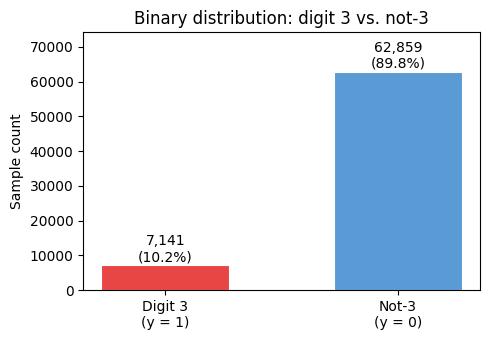

In [5]:
# ── Figure: class_dist_binary ─────────────────────────────────────────────
# Binary class distribution visualised as a bar + percentage labels.

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar([f'Digit {TARGET_DIGIT}\n(y = 1)', f'Not-{TARGET_DIGIT}\n(y = 0)'],
              [n_pos, n_neg],
              color=['#e84545', '#5b9bd5'], edgecolor='white', linewidth=0.8,
              width=0.55)
for bar, c, pct in zip(bars, [n_pos, n_neg], [pos_rate, 1 - pos_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{c:,}\n({pct*100:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Sample count')
ax.set_title(f'Binary distribution: digit {TARGET_DIGIT} vs. not-{TARGET_DIGIT}')
ax.set_ylim(0, n_neg * 1.18)
plt.tight_layout()
plt.show()

# 4. Data Processing

The pipeline follows these **ordered** steps to prevent data leakage:

```
Raw images (70 000 × 28 × 28)
  │
  ▼ 4.1  Normalise pixels  ÷255  →  [0,1]
  │
  ├─▶ 4.2a  Flatten       →  784-dim vectors
  ├─▶ 4.2b  PCA (k=50)    →  50-dim  (fit on train only)
  └─▶ 4.2c  HOG           →  1296-dim
  │
  ▼ 4.3  Stratified split  →  70% train / 15% val / 15% test
  │
  ▼ 4.4  StandardScaler    →  z-score  (fit on train only)
```

### 4.1 · Image Normalisation

**Math:** $x'_{ij} = x_{ij} / 255$, mapping $\{0,\ldots,255\} \to [0, 1]$.

**Why needed:**
- Gradient descent converges faster when features are on similar scales.
- Prevents numerical overflow in dot products.
- Keeps pixel 0 (background) at exactly 0.

This is **not** data-dependent (divides by a fixed constant 255), so it does **not** constitute data leakage even if applied before splitting.

In [6]:
# Normalise: uint8 [0,255]  →  float32 [0,1]
X_norm = X_raw.astype(np.float32) / 255.0

print(f'Before normalisation:  dtype={X_raw.dtype},  range=[{X_raw.min()}, {X_raw.max()}]')
print(f'After normalisation:   dtype={X_norm.dtype},  range=[{X_norm.min():.3f}, {X_norm.max():.3f}]')

Before normalisation:  dtype=uint8,  range=[0, 255]
After normalisation:   dtype=float32,  range=[0.000, 1.000]


### 4.2 · Feature Extraction

We extract **three independent feature representations** from the same normalised images. Models will later be trained on each separately so we can identify the best descriptor.

| Method | Formula | Output dim | Key idea |
|--------|---------|-----------|----------|
| Flatten | $\mathbf{x} = \text{vec}(I)$ | 784 | All pixels as a vector |
| PCA | $\mathbf{z} = W_k^\top(\mathbf{x}-\bar{\mathbf{x}})$ | 50 | Top-variance linear subspace |
| HOG | cell gradient histograms + block norm | 1296 | Edge-orientation descriptor |

#### 4.2a · Flattening

$$\text{vec}: \mathbb{R}^{H \times W} \to \mathbb{R}^{HW}, \quad
x_k = I_{\lceil k/W \rceil, ((k-1)\bmod W)+1}$$

Row-major (C-order) flattening for MNIST ($H=W=28$) gives $\mathbf{x} \in \mathbb{R}^{784}$.

**Why it's the baseline:** Logistic regression on flat pixels is a well-known strong baseline for MNIST that consistently reaches >97% accuracy on the full 10-class task. Any more sophisticated feature extractor must beat it.

In [7]:
# Reshape (N, 28, 28) → (N, 784)  using C-order (row-major)
X_flat = X_norm.reshape(len(X_norm), -1)

print(f'Flatten: {X_norm.shape}  →  {X_flat.shape}')
print(f'  dtype: {X_flat.dtype}')
print(f'  Sparsity: {(X_flat == 0).mean()*100:.1f}% zero entries (background pixels)')

Flatten: (70000, 28, 28)  →  (70000, 784)
  dtype: float32
  Sparsity: 80.9% zero entries (background pixels)


#### 4.2b · PCA — Principal Component Analysis

**Steps:**
1. Centre the data: $\tilde{X} = X - \mathbf{1}\bar{\mathbf{x}}^\top$
2. Covariance: $C = \frac{1}{n-1}\tilde{X}^\top\tilde{X} \in \mathbb{R}^{d \times d}$
3. Eigendecompose: $C = W\Lambda W^\top$ (eigenvectors sorted by $\lambda_j \downarrow$)
4. Project: $\mathbf{z} = W_k^\top\tilde{\mathbf{x}} \in \mathbb{R}^k$

**Critical:** PCA is **fit on training data only** and the same transformation is applied to val/test. Fitting on all data would leak test-set statistics into the projection matrix.

In [ ]:
N_PCA_COMPONENTS = 50

# Fit PCA on a training-only subset to preview variance explained.
# The definitive PCA used for model training is re-fit in Section 4.3.
X_flat_tr_tmp, _, _, _ = train_test_split(
    X_flat, y_binary, test_size=0.30, stratify=y_binary, random_state=42
)

pca_preview = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
pca_preview.fit(X_flat_tr_tmp)

ev_total = pca_preview.explained_variance_ratio_.sum() * 100

print(f'PCA preview (fit on training subset only):')
print(f'  Components   : {N_PCA_COMPONENTS}')
print(f'  Total variance explained: {ev_total:.2f}%')
print(f'  Compression  : {X_flat.shape[1]/N_PCA_COMPONENTS:.1f}x  '
      f'({X_flat.shape[1]} -> {N_PCA_COMPONENTS} features)')

#### 4.2c · HOG — Histogram of Oriented Gradients

**Step-by-step math:**

1. **Gradients:** $g_x = I * [-1,0,1]$, $g_y = I * [-1,0,1]^\top$
2. **Magnitude & orientation:** $m_{ij} = \sqrt{g_x^2 + g_y^2}$, $\theta_{ij} = \arctan(g_y/g_x) \pmod{\pi}$
3. **Cell histograms:** 9-bin histogram per 4×4-pixel cell, weighted by magnitude
4. **Block normalisation (L2-Hys):** normalise 2×2-cell blocks, clip to 0.2, renormalise

**Descriptor dimension:** $(7-2+1) \times (7-2+1) \times 2 \times 2 \times 9 = 1296$ features

**Configuration used:**
- `orientations=9`, `pixels_per_cell=(4,4)`, `cells_per_block=(2,2)`, `block_norm='L2-Hys'`

In [ ]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
)

def extract_hog(images, params, visualize=False):
    """Extract HOG features from a batch of (N, H, W) float images."""
    feats, vis_imgs = [], []
    for img in images:
        if visualize:
            feat, vis = hog(img, visualize=True, **params)
            vis_imgs.append(vis)
        else:
            feat = hog(img, visualize=False, **params)
        feats.append(feat)
    return np.array(feats), (np.array(vis_imgs) if visualize else None)

print('Extracting HOG features (full dataset - may take 1-2 min)...')
X_hog, _ = extract_hog(X_norm, HOG_PARAMS, visualize=False)
print(f'HOG: {X_norm.shape}  ->  {X_hog.shape}')
print(f'  Parameters: {HOG_PARAMS}')
print(f'  Dimension check: 6x6 blocks x 4 cells/block x 9 orientations = '
      f'{6*6*4*9}')

In [ ]:
def _cell_hog_vectors(image, pixels_per_cell=(4, 4), orientations=9):
    gy = np.gradient(image.astype(np.float64), axis=0)
    gx = np.gradient(image.astype(np.float64), axis=1)
    mag = np.hypot(gx, gy)
    ang = np.arctan2(gy, gx)
    cpy, cpx = pixels_per_cell
    n_cells_y = image.shape[0] // cpy
    n_cells_x = image.shape[1] // cpx
    angle_grid = np.zeros((n_cells_y, n_cells_x))
    mag_grid   = np.zeros((n_cells_y, n_cells_x))
    bin_edges = np.linspace(-np.pi, np.pi, orientations + 1)
    for cy in range(n_cells_y):
        for cx in range(n_cells_x):
            patch_mag = mag[cy*cpy:(cy+1)*cpy, cx*cpx:(cx+1)*cpx]
            patch_ang = ang[cy*cpy:(cy+1)*cpy, cx*cpx:(cx+1)*cpx]
            hist, _ = np.histogram(patch_ang.ravel(), bins=bin_edges, weights=patch_mag.ravel())
            dominant_bin = np.argmax(hist)
            angle_grid[cy, cx] = (bin_edges[dominant_bin] + bin_edges[dominant_bin + 1]) / 2.0
            mag_grid[cy, cx] = hist[dominant_bin]
    return angle_grid, mag_grid

def draw_hog_vectors(ax, image, pixels_per_cell=(4, 4), orientations=9, cmap='inferno', arrow_scale=0.42, linewidth=0.8):
    ang, mag = _cell_hog_vectors(image, pixels_per_cell, orientations)
    cpy, cpx = pixels_per_cell
    n_cells_y, n_cells_x = ang.shape
    cx_coords = np.arange(n_cells_x) * cpx + cpx / 2.0
    cy_coords = np.arange(n_cells_y) * cpy + cpy / 2.0
    CX, CY = np.meshgrid(cx_coords, cy_coords)
    norm_mag = mag / (mag.max() + 1e-8)
    U =  np.cos(ang) * norm_mag
    V = -np.sin(ang) * norm_mag
    ax.imshow(image, cmap='gray', alpha=0.35)
    colormap = cm.get_cmap(cmap)
    normalizer = Normalize(vmin=0, vmax=1)
    colors = colormap(normalizer(norm_mag.ravel()))
    ax.quiver(CX, CY, U, V, color=colors, scale=arrow_scale * max(n_cells_x, n_cells_y),
              scale_units='width', headaxislength=4, headlength=5, headwidth=3.5,
              linewidth=linewidth, pivot='middle')
    ax.set_xlim(-0.5, image.shape[1] - 0.5)
    ax.set_ylim(image.shape[0] - 0.5, -0.5)
    ax.axis('off')

N_VIS = 6
idx_pos = np.random.choice(np.where(y_binary == 1)[0], N_VIS // 2, replace=False)
idx_neg = np.random.choice(np.where(y_binary == 0)[0], N_VIS // 2, replace=False)
vis_indices = np.concatenate([idx_pos, idx_neg])
labels_text = ['digit 3'] * (N_VIS // 2) + ['not-3'] * (N_VIS // 2)
colors_title = ['#e84545'] * (N_VIS // 2) + ['#5b9bd5'] * (N_VIS // 2)
fig, axes = plt.subplots(3, N_VIS, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1, 0.06]})
for i in range(N_VIS):
    img = X_norm[vis_indices[i]]
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{labels_text[i]}\n(y={y_binary[vis_indices[i]]})', fontsize=8, fontweight='bold', color=colors_title[i])
    axes[0, i].axis('off')
    draw_hog_vectors(axes[1, i], img, pixels_per_cell=HOG_PARAMS.get('pixels_per_cell', (4, 4)), orientations=HOG_PARAMS.get('orientations', 9), cmap='inferno')
axes[0, 0].set_ylabel('Original', fontsize=10, rotation=90, labelpad=30)
axes[1, 0].set_ylabel('HOG vectors', fontsize=10, rotation=90, labelpad=30)
sm = cm.ScalarMappable(cmap='inferno', norm=Normalize(0, 1))
sm.set_array([])
for a in axes[2]:
    a.axis('off')
cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.018])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('Relative gradient magnitude', fontsize=9)
cb.ax.tick_params(labelsize=7)
fig.suptitle('HOG visualisation — directional vectors coloured by gradient strength', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.show()

### 4.3 · Train / Validation / Test Split

Stratified 70 / 15 / 15 split. The same `random_state=42` is applied across all feature sets to guarantee identical sample assignment.

In [ ]:
# ── Definitive Train / Validation / Test Split (stratified, 70 / 15 / 15) ──
# Split indices across all feature sets using the same random_state
# to guarantee identical sample assignment.

X_flat_tr, X_flat_tmp, y_tr, y_tmp = train_test_split(
    X_flat, y_binary,
    test_size=0.30,
    stratify=y_binary,
    random_state=42
)
X_flat_val, X_flat_te, y_val, y_te = train_test_split(
    X_flat_tmp, y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=42
)

# PCA: re-fit on training split only (no leakage)
pca_final = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca_tr  = pca_final.fit_transform(X_flat_tr)
X_pca_val = pca_final.transform(X_flat_val)
X_pca_te  = pca_final.transform(X_flat_te)

# HOG: use same indices
indices = np.arange(len(X_hog))
idx_tr, idx_tmp = train_test_split(indices, test_size=0.30, stratify=y_binary, random_state=42)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=y_binary[idx_tmp], random_state=42)
X_hog_tr  = X_hog[idx_tr]
X_hog_val = X_hog[idx_val]
X_hog_te  = X_hog[idx_te]

print('Three-way stratified split (70 / 15 / 15)')
print(f'  Train : {X_flat_tr.shape[0]:>6,}  |  pos={y_tr.sum():,}  ({y_tr.mean()*100:.2f}%)')
print(f'  Val   : {X_flat_val.shape[0]:>6,}  |  pos={y_val.sum():,}  ({y_val.mean()*100:.2f}%)')
print(f'  Test  : {X_flat_te.shape[0]:>6,}  |  pos={y_te.sum():,}  ({y_te.mean()*100:.2f}%)')

### 4.4 · Feature Standardization

`StandardScaler` fit on the training split only, then applied to val and test — no data leakage.

In [ ]:
# Flatten
scaler_flat = StandardScaler()
Xtr_flat_sc  = scaler_flat.fit_transform(X_flat_tr)
Xval_flat_sc = scaler_flat.transform(X_flat_val)
Xte_flat_sc  = scaler_flat.transform(X_flat_te)

# PCA
scaler_pca = StandardScaler()
Xtr_pca_sc  = scaler_pca.fit_transform(X_pca_tr)
Xval_pca_sc = scaler_pca.transform(X_pca_val)
Xte_pca_sc  = scaler_pca.transform(X_pca_te)

# HOG
scaler_hog = StandardScaler()
Xtr_hog_sc  = scaler_hog.fit_transform(X_hog_tr)
Xval_hog_sc = scaler_hog.transform(X_hog_val)
Xte_hog_sc  = scaler_hog.transform(X_hog_te)

# 5. Class Imbalance Handling

Two strategies: inverse-frequency class weighting and SMOTE oversampling, both from scratch. Applied to training folds only — never to val or test data.

In [13]:
def compute_class_weights(y, num_classes=2):
    """Computes weights inversely proportional to class frequency."""
    N = len(y)
    weights = np.zeros(num_classes)
    for c in range(num_classes):
        count_c = np.sum(y == c)
        if count_c > 0:
            weights[c] = N / (num_classes * count_c)
    return weights

def apply_smote(X, y, num_classes=2, k_neighbors=5):
    """
    Generates synthetic minority samples using SMOTE to equalize distribution.
    Built from scratch using NumPy.
    """
    counts = [np.sum(y == c) for c in range(num_classes)]
    max_count = max(counts)
    
    X_res_list = [X]
    y_res_list = [y]
    
    for c in range(num_classes):
        idx = np.where(y == c)[0]
        count_c = len(idx)
        
        # Skip if majority class or empty
        if count_c == 0 or count_c == max_count:
            continue
            
        needed = max_count - count_c
        X_c = X[idx]
        
        # If a class is exceptionally small, cap k_neighbors to avoid index errors
        k = min(k_neighbors, count_c - 1)
        if k <= 0:
            # Fallback to exact duplication if only 1 sample exists in the class
            dup_idx = np.random.choice(idx, size=needed, replace=True)
            X_res_list.append(X[dup_idx])
            y_res_list.append(y[dup_idx])
            continue
            
        # 1. Compute pairwise squared Euclidean distances within the minority class
        diff = X_c[:, np.newaxis, :] - X_c[np.newaxis, :, :]
        dists = np.sum(diff**2, axis=2)
        
        # 2. Find the K nearest neighbors (start from 1 to exclude the point itself)
        nn_idx = np.argsort(dists, axis=1)[:, 1:k+1]
        
        # 3. Generate synthetic samples
        synthetic_X = np.zeros((needed, X.shape[1]))
        synthetic_y = np.full(needed, c)
        
        for i in range(needed):
            # Pick a random minority sample
            base_idx = np.random.randint(0, count_c)
            # Pick a random neighbor of that sample
            neighbor_idx = np.random.choice(nn_idx[base_idx])
            
            # Interpolate: X_new = X_base + lambda * (X_neighbor - X_base)
            step = np.random.rand()
            synthetic_X[i] = X_c[base_idx] + step * (X_c[neighbor_idx] - X_c[base_idx])
            
        X_res_list.append(synthetic_X)
        y_res_list.append(synthetic_y)
        
    # Combine original data with all new synthetic data
    X_res = np.vstack(X_res_list)
    y_res = np.concatenate(y_res_list)
    
    # Shuffle the final dataset
    shuff_idx = np.random.permutation(len(y_res))
    return X_res[shuff_idx], y_res[shuff_idx]

    
def create_stratified_folds(y, b_folds, num_classes=2):
    """Returns a list of indices representing B equal-sized stratified folds."""
    folds = [[] for _ in range(b_folds)]
    for c in range(num_classes):
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)
        splits = np.array_split(idx, b_folds)
        for b in range(b_folds):
            folds[b].extend(splits[b])
    for b in range(b_folds):
        np.random.shuffle(folds[b])
        folds[b] = np.array(folds[b])
    return folds

# 6. Evaluation Metrics (From Scratch)

Computes confusion matrix, per-class precision / recall / F1, and macro / weighted aggregates — all with NumPy, no sklearn.

In [14]:
def compute_confusion_matrix(y_true, y_pred, num_classes=2):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def evaluate(y_true, y_pred, class_weights=None, num_classes=2):
    cm = compute_confusion_matrix(y_true, y_pred, num_classes)
    accuracy = np.trace(cm) / np.sum(cm) if np.sum(cm) > 0 else 0.0
    
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision+recall)!=0)
    
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)
    
    if class_weights is None:
        class_weights = np.ones(num_classes)
    w_sum = np.sum(class_weights)
    norm_w = class_weights / w_sum if w_sum > 0 else class_weights
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': np.sum(precision * norm_w),
        'weighted_recall': np.sum(recall * norm_w),
        'weighted_f1': np.sum(f1 * norm_w)
    }

def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    fig.colorbar(im)
    tick_marks = np.arange(cm.shape[0])
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

# 7. Batch Training Pipeline & Results

25-fold stratified cross-validation across all (model × feature) combinations. Each model is then re-trained on the full training set and evaluated on the held-out test set.

──────── Logistic Regression ────────
  Fold 01/25 - train=2704, val=1961
  Fold 02/25 - train=2702, val=1960
  Fold 03/25 - train=2708, val=1960
  Fold 04/25 - train=2720, val=1960
  Fold 05/25 - train=2670, val=1960
  Fold 06/25 - train=2652, val=1960
  Fold 07/25 - train=2678, val=1960
  Fold 08/25 - train=2680, val=1960
  Fold 09/25 - train=2678, val=1960
  Fold 10/25 - train=2686, val=1960
  Fold 11/25 - train=2686, val=1960
  Fold 12/25 - train=2666, val=1960
  Fold 13/25 - train=2706, val=1960
  Fold 14/25 - train=2666, val=1960
  Fold 15/25 - train=2702, val=1960
  Fold 16/25 - train=2712, val=1960
  Fold 17/25 - train=2696, val=1960
  Fold 18/25 - train=2680, val=1960
  Fold 19/25 - train=2702, val=1960
  Fold 20/25 - train=2686, val=1960
  Fold 21/25 - train=2692, val=1960
  Fold 22/25 - train=2710, val=1960
  Fold 23/25 - train=2630, val=1960
  Fold 24/25 - train=2710, val=1960
  Fold 25/25 - train=2686, val=1959
  [CV] Accuracy: 0.7313 +/- 0.0134  |  W-F1: 0.4658 +/- 0.0114

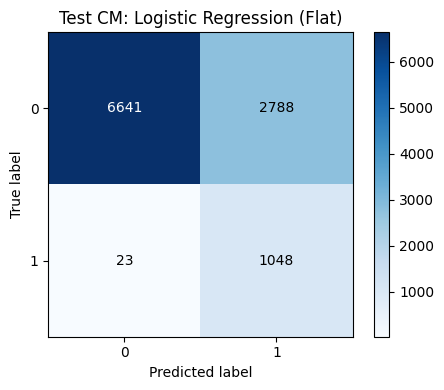

──────── KNN ────────
  Fold 01/25 - train=2704, val=1961
  Fold 02/25 - train=2656, val=1960
  Fold 03/25 - train=2660, val=1960
  Fold 04/25 - train=2718, val=1960
  Fold 05/25 - train=2714, val=1960
  Fold 06/25 - train=2658, val=1960
  Fold 07/25 - train=2714, val=1960
  Fold 08/25 - train=2684, val=1960
  Fold 09/25 - train=2698, val=1960
  Fold 10/25 - train=2666, val=1960
  Fold 11/25 - train=2684, val=1960
  Fold 12/25 - train=2708, val=1960
  Fold 13/25 - train=2676, val=1960
  Fold 14/25 - train=2700, val=1960
  Fold 15/25 - train=2738, val=1960
  Fold 16/25 - train=2740, val=1960
  Fold 17/25 - train=2662, val=1960
  Fold 18/25 - train=2684, val=1960
  Fold 19/25 - train=2668, val=1960
  Fold 20/25 - train=2706, val=1960
  Fold 21/25 - train=2670, val=1960
  Fold 22/25 - train=2700, val=1960
  Fold 23/25 - train=2650, val=1960
  Fold 24/25 - train=2708, val=1960
  Fold 25/25 - train=2664, val=1959
  [CV] Accuracy: 0.9021 +/- 0.0083  |  W-F1: 0.6983 +/- 0.0164
  Retraining on

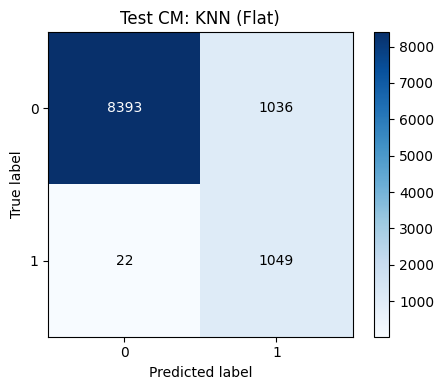

──────── SVC ────────
  Fold 01/25 - train=2668, val=1961
  Fold 02/25 - train=2698, val=1960
  Fold 03/25 - train=2718, val=1960
  Fold 04/25 - train=2666, val=1960
  Fold 05/25 - train=2672, val=1960
  Fold 06/25 - train=2720, val=1960
  Fold 07/25 - train=2644, val=1960
  Fold 08/25 - train=2710, val=1960
  Fold 09/25 - train=2688, val=1960
  Fold 10/25 - train=2670, val=1960
  Fold 11/25 - train=2694, val=1960
  Fold 12/25 - train=2684, val=1960
  Fold 13/25 - train=2700, val=1960
  Fold 14/25 - train=2718, val=1960
  Fold 15/25 - train=2656, val=1960
  Fold 16/25 - train=2702, val=1960
  Fold 17/25 - train=2676, val=1960
  Fold 18/25 - train=2698, val=1960
  Fold 19/25 - train=2674, val=1960
  Fold 20/25 - train=2700, val=1960
  Fold 21/25 - train=2682, val=1960
  Fold 22/25 - train=2686, val=1960
  Fold 23/25 - train=2680, val=1960
  Fold 24/25 - train=2652, val=1960
  Fold 25/25 - train=2670, val=1959
  [CV] Accuracy: 0.9713 +/- 0.0050  |  W-F1: 0.8609 +/- 0.0260
  Retraining on

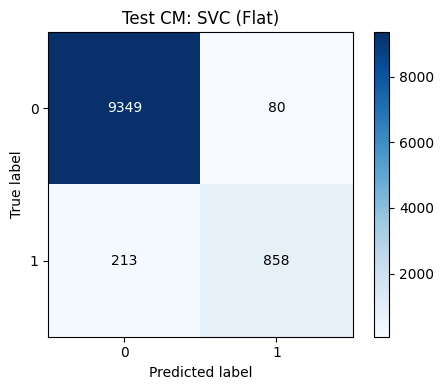

| Model (Feature)                      | Accuracy | W-Prec.  | W-Recall |   W-F1   |
|--------------------------------------+----------+----------+----------+----------+
| Logistic Regression (Flat)           | 0.7323   | 0.3470   | 0.9505   | 0.4678   |
| KNN (Flat)                           | 0.8992   | 0.5535   | 0.9703   | 0.6929   |
| SVC (Flat)                           | 0.9721   | 0.9211   | 0.8205   | 0.8675   |


In [15]:
B_FOLDS = 25
USE_OVERSAMPLING = True
SUBSAMPLE_SIZE = 1500  # Cap training subset for slower algorithms (KNN, SVC)
NUM_CLASSES = 2

base_weights = compute_class_weights(y_tr, NUM_CLASSES)
folds_idx    = create_stratified_folds(y_tr, B_FOLDS, NUM_CLASSES)

pipeline_configs = [
    ('Logistic Regression', LogisticRegression,   {'lr': 0.01, 'max_iter': 100, 'C': 1.0}),
    ('KNN',                 KNeighborsClassifier, {'n_neighbors': 5, 'weights': 'uniform', 'p': 2}),
    ('SVC',                 SVC,                  {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'max_iter': 100}),
]

summary_results = []
trained_models  = {}

for model_name, ModelClass, kwargs in pipeline_configs:
    print(f"{'─'*8} {model_name} {'─'*8}")
    fold_metrics = []

    for b in range(B_FOLDS):
        val_idx   = folds_idx[b]
        train_idx = np.concatenate([folds_idx[i] for i in range(B_FOLDS) if i != b])

        X_batch_tr,  y_batch_tr  = Xtr_flat_sc[train_idx], y_tr[train_idx]
        X_batch_val, y_batch_val = Xtr_flat_sc[val_idx],   y_tr[val_idx]

        if SUBSAMPLE_SIZE is not None and len(X_batch_tr) > SUBSAMPLE_SIZE:
            sub_idx = np.random.choice(len(X_batch_tr), SUBSAMPLE_SIZE, replace=False)
            X_batch_tr, y_batch_tr = X_batch_tr[sub_idx], y_batch_tr[sub_idx]

        if USE_OVERSAMPLING:
            X_batch_tr, y_batch_tr = apply_smote(
                X_batch_tr, y_batch_tr, NUM_CLASSES, k_neighbors=5)

        print(f'  Fold {b+1:02d}/{B_FOLDS} - train={len(X_batch_tr)}, val={len(X_batch_val)}')

        model = ModelClass(**kwargs)
        model.fit(X_batch_tr, y_batch_tr)

        y_pred  = model.predict(X_batch_val)
        metrics = evaluate(y_batch_val, y_pred,
                           class_weights=base_weights, num_classes=NUM_CLASSES)
        fold_metrics.append(metrics)

    accs = [m['accuracy']    for m in fold_metrics]
    w_f1 = [m['weighted_f1'] for m in fold_metrics]
    print(f'  [CV] Accuracy: {np.mean(accs):.4f} +/- {np.std(accs):.4f}'
          f'  |  W-F1: {np.mean(w_f1):.4f} +/- {np.std(w_f1):.4f}')

    # Re-train on the full training set for held-out test evaluation
    X_full_tr = Xtr_flat_sc.copy()
    y_full_tr = y_tr.copy()

    if SUBSAMPLE_SIZE is not None and len(X_full_tr) > SUBSAMPLE_SIZE:
        sub_idx = np.random.choice(len(X_full_tr), SUBSAMPLE_SIZE, replace=False)
        X_full_tr, y_full_tr = X_full_tr[sub_idx], y_full_tr[sub_idx]

    if USE_OVERSAMPLING:
        X_full_tr, y_full_tr = apply_smote(
            X_full_tr, y_full_tr, NUM_CLASSES, k_neighbors=5)

    print('  Retraining on full training set...')
    final_model = ModelClass(**kwargs)
    final_model.fit(X_full_tr, y_full_tr)

    y_te_pred    = final_model.predict(Xte_flat_sc)
    test_metrics = evaluate(y_te, y_te_pred,
                            class_weights=base_weights, num_classes=NUM_CLASSES)

    run_key = f'{model_name} (Flat)'
    summary_results.append({
        'Model':    run_key,
        'Feature':  'Flat',
        'Accuracy': test_metrics['accuracy'],
        'W-Prec.':  test_metrics['weighted_precision'],
        'W-Recall': test_metrics['weighted_recall'],
        'W-F1':     test_metrics['weighted_f1'],
    })
    trained_models[run_key] = final_model
    plot_confusion_matrix(test_metrics['confusion_matrix'],
                          title=f'Test CM: {run_key}')

# ── Summary table ─────────────────────────────────────────────────────────────
W = 36
hdr = '| {:<{w}} | {:^8} | {:^8} | {:^8} | {:^8} |'.format(
    'Model (Feature)', 'Accuracy', 'W-Prec.', 'W-Recall', 'W-F1', w=W)
sep = '|' + '-'*(W+2) + '+----------+----------+----------+----------+'
print('' + hdr)
print(sep)
for res in summary_results:
    print('| {:<{w}} | {:.4f}   | {:.4f}   | {:.4f}   | {:.4f}   |'.format(
        res['Model'], res['Accuracy'], res['W-Prec.'],
        res['W-Recall'], res['W-F1'], w=W))

Generating Pipeline Visualizations...


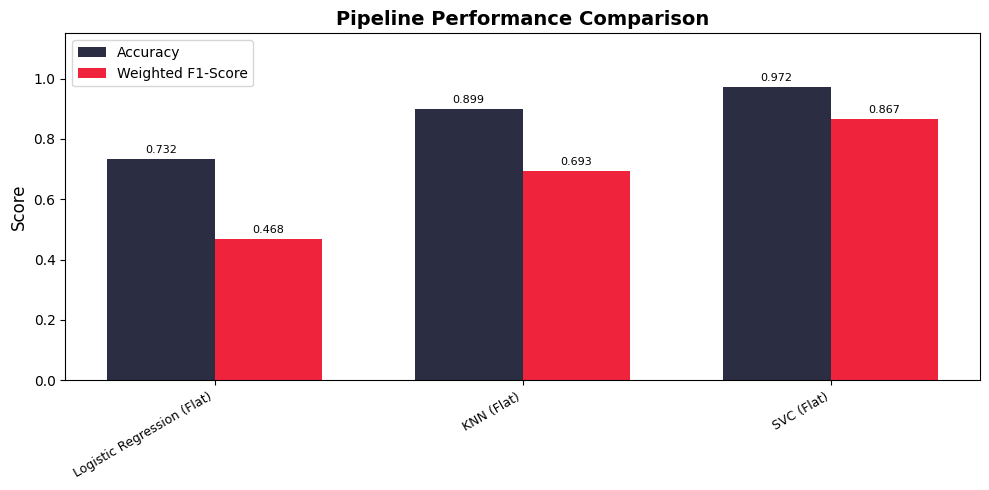

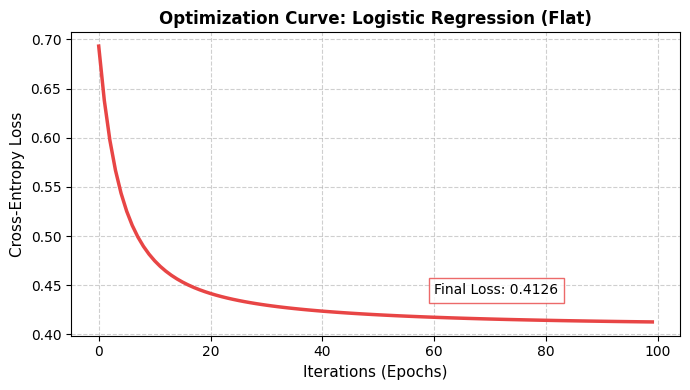

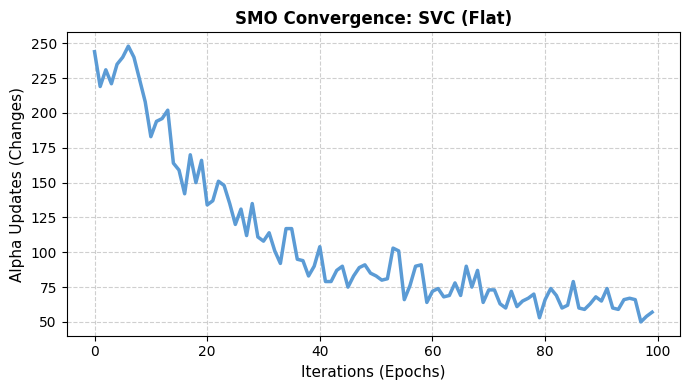

In [16]:
def plot_model_optimization(model, model_name):
    """Plots the optimization or convergence curve for Logistic Regression or SVC."""
    if not hasattr(model, 'loss_histories_'):
        print(f'{model_name} does not use iterative optimization.')
        return

    history = model.loss_histories_[0]
    fig, ax = plt.subplots(figsize=(7, 4))

    if isinstance(model, LogisticRegression):
        ax.plot(history, color='#e84545', linewidth=2.5)
        ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
        ax.set_title(f'Optimization Curve: {model_name}', fontweight='bold')
        final_loss = history[-1]
        y_range = max(history) - min(history) + 1e-8
        ax.text(len(history) * 0.60, final_loss + y_range * 0.10,
                f'Final Loss: {final_loss:.4f}',
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='#e84545'))
    elif isinstance(model, SVC):
        ax.plot(history, color='#5b9bd5', linewidth=2.5)
        ax.set_ylabel('Alpha Updates (Changes)', fontsize=11)
        ax.set_title(f'SMO Convergence: {model_name}', fontweight='bold')

    ax.set_xlabel('Iterations (Epochs)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_pipeline_stability(summary_results):
    """Grouped bar chart comparing Accuracy and Weighted F1 across all runs."""
    if not summary_results:
        return

    labels = [res['Model']    for res in summary_results]
    acc    = [res['Accuracy'] for res in summary_results]
    f1     = [res['W-F1']    for res in summary_results]

    x     = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.5), 5))
    ax.bar(x - width/2, acc, width, label='Accuracy',          color='#2b2d42')
    ax.bar(x + width/2, f1,  width, label='Weighted F1-Score', color='#ef233c')

    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Pipeline Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=30, ha='right')
    ax.set_ylim(0, 1.15)
    ax.legend()

    for i, v in enumerate(acc):
        ax.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)
    for i, v in enumerate(f1):
        ax.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()


print('Generating Pipeline Visualizations...')
plot_pipeline_stability(summary_results)

# Plot optimization curves for one LR model and one SVC model
lr_key  = next((k for k in trained_models if k.startswith('Logistic Regression')), None)
svc_key = next((k for k in trained_models if k.startswith('SVC')), None)
if lr_key:
    plot_model_optimization(trained_models[lr_key], lr_key)
if svc_key:
    plot_model_optimization(trained_models[svc_key], svc_key)


In [ ]:
# ── 1. Create a 2D Dataset for Visualization ─────────────────────────────────
X_2d, y_2d = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

print("Training SVC on 2D data...")
svc_2d = SVC(C=1.0, kernel='rbf', max_iter=200)
svc_2d.fit(X_2d, y_2d)

# ── 2. Plot the Alpha Updates (Convergence) ──────────────────────────────────
def plot_svc_convergence(model):
    """Plots how many alphas were updated per iteration."""
    updates = model.loss_histories_[0]
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(updates, color='#5b9bd5', linewidth=2.5, marker='o', markersize=4)
    ax.set_title("SMO Convergence: Alpha Updates per Iteration", fontweight='bold')
    ax.set_xlabel("Iteration (Epoch)")
    ax.set_ylabel("Number of Alpha Updates")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ── 3. Plot the Decision Boundary & Support Vectors ──────────────────────────
def plot_svc_decision_boundary(model, X, y):
    """Plots the 2D data, the margin line, and highlights Support Vectors."""
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=40, edgecolors='k', alpha=0.8)    
    alpha, b, sv_X, sv_y = model._models[0]    
    ax.scatter(sv_X[:, 0], sv_X[:, 1], s=150, facecolors='none', 
               edgecolors='gold', linewidths=2.5, label='Support Vectors')

    # Create a grid to draw the boundary
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Calculate the distance from the boundary for the grid
    Z = model._decision_binary(xy, model._models[0])
    Z = Z.reshape(XX.shape)

    # Draw the boundary (Z=0) and the Margins (Z=-1, Z=1)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'])

    ax.set_title(f"SVC Decision Boundary & Margins (Kernel: {model.kernel})", fontweight='bold')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# ── Execute the Plots ────────────────────────────────────────────────────────
plot_svc_convergence(svc_2d)
plot_svc_decision_boundary(svc_2d, X_2d, y_2d)